In [9]:
print("Everything is working fine!")

Everything is working fine!


In [10]:
# Creating environment variables for API keys

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["WEATHER_API_KEY"] = os.getenv("WEATHER_API_KEY")

In [11]:
# Loading the LLM

from langchain_groq import ChatGroq

llm = ChatGroq(model = "llama-3.3-70b-versatile")


e:\Agents_Langgraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# Defining the tools
import requests
from langchain_core.tools import tool
from langchain_tavily import TavilySearch


@tool
def get_weather(query: str) -> list:
    """Search weatherapi to get the current weather"""
    endpoint = f"http://api.weatherapi.com/v1/current.json?key={WEATHER_API_KEY}&q={query}"
    response = requests.get(endpoint)
    data = response.json()

    if response.status_code != 200: 
        return f"Unable to fetch weather for {query}"
    
    data = response.json()
    
    location = data["location"]["name"] 
    country = data["location"]["country"] 
    temp = data["current"]["temp_c"] 
    condition = data["current"]["condition"]["text"] 
    humidity = data["current"]["humidity"] 
    wind = data["current"]["wind_kph"] 
    
    return ( 
            "Weather in {location}, {country}: " 
            f"{temp}°C, {condition}, " 
            f"Humidity: {humidity}%, Wind: {wind} kph" )

@tool
def search_web(query: str) -> list:
    """Search the web for a query"""
    tavily_search = TavilySearch(api_key=TAVILY_API_KEY, max_results=2, search_depth='advanced', max_tokens=1000)
    results = tavily_search.invoke(query)
    return results

In [13]:
# Binding the tools to the LLM

llm_with_tools = llm.bind_tools([get_weather, search_web])

In [14]:
llm_with_tools 

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F468B20110>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F468BC2110>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_weather', 'description': 'Search weat

In [16]:
# Prompting the LLM with a query that requires tool calls

prompt = """
    Given only the tools at your disposal, mention tool calls for the following tasks:
    Do not change the query given for any search tasks
        1. What is the current weather in Delhi today?
        2. Can you tell me about Kerala?
        3. Why is the sky blue?
    """

In [17]:
results = llm_with_tools.invoke(prompt)

print(results.tool_calls)

[{'name': 'get_weather', 'args': {'query': 'Delhi'}, 'id': 'ncgbjzfs1', 'type': 'tool_call'}, {'name': 'search_web', 'args': {'query': 'Kerala'}, 'id': '6sar2gfje', 'type': 'tool_call'}, {'name': 'search_web', 'args': {'query': 'Why is the sky blue'}, 'id': '79pe808n0', 'type': 'tool_call'}]


In [18]:
results

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ncgbjzfs1', 'function': {'arguments': '{"query":"Delhi"}', 'name': 'get_weather'}, 'type': 'function'}, {'id': '6sar2gfje', 'function': {'arguments': '{"query":"Kerala"}', 'name': 'search_web'}, 'type': 'function'}, {'id': '79pe808n0', 'function': {'arguments': '{"query":"Why is the sky blue"}', 'name': 'search_web'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 331, 'total_tokens': 377, 'completion_time': 0.10783533, 'completion_tokens_details': None, 'prompt_time': 0.059199103, 'prompt_tokens_details': None, 'queue_time': 0.161804494, 'total_time': 0.167034433}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fdb97-2dc4-7dd0-9797-7d684c0e893a-0', tool_calls=[{'name': 'get_weather', 'args': {'query': 'Delhi'}, 'id': 'n

In [21]:
query = "What is the current weather in Delhi today?"
response = llm.invoke(query)
print(response.content)

I'm an AI, and I don't have real-time access to current weather conditions. However, I can suggest some ways for you to find out the current weather in Delhi.

You can check the current weather in Delhi by:

1. Visiting a weather website such as AccuWeather, Weather.com, or the Indian Meteorological Department's website.
2. Using a mobile app like Dark Sky, Weather Underground, or The Weather Channel.
3. Checking social media platforms like Twitter or Facebook for updates from weather forecasting agencies or news organizations.
4. Tune into local news channels or radio stations for weather updates.

Please note that the weather can change rapidly, so it's always a good idea to check for updates frequently.


In [22]:
# State Schema for the message state
from typing import TypedDict, Optional

class AgentState(TypedDict): 
    query: str 
    decision: Optional[str] 
    weather_result: Optional[str] 
    search_result: Optional[str] 
    final_response: Optional[str]

In [23]:
def get_weather(city: str) -> str: 
    url = "http://api.weatherapi.com/v1/current.json" 
    params = { "key": os.getenv("WEATHER_API_KEY"), 
              "q": city, 
              "aqi": "no" } 
    
    response = requests.get(url, params=params) 
    
    if response.status_code != 200: 
        return f"Could not fetch weather for {city}" 
    
    data = response.json() 
    
    return ( 
            f"{data['location']['name']}, " 
            f"{data['location']['country']}: " 
            f"{data['current']['temp_c']}°C, " 
            f"{data['current']['condition']['text']}, " 
            f"Humidity {data['current']['humidity']}%, " 
            f"Wind {data['current']['wind_kph']} kph" 
            )

In [24]:
get_weather("Delhi, India")

'Delhi, India: 32.7°C, Patchy rain nearby, Humidity 58%, Wind 14.8 kph'

In [25]:
from langchain_tavily import TavilySearch

def search_web(query: str) -> str: 
    
    tavily_search = TavilySearch() 
    results = tavily_search.invoke(query) 
    return results

In [26]:
search_web("Tell me latest news about AI")

{'query': 'Tell me latest news about AI',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.artificialintelligence-news.com',
   'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
   'content': 'July 30, 2026\n\n### Google’s Gemini 3.6 Flash targets enterprise agent token costs\n\nAI in Action\n\nJuly 21, 2026\n\n### HP accelerates enterprise workflows with OpenAI Frontier\n\nWorld of Work\n\nJune 29, 2026\n\n#### Deep Learning\n\n### Aviva deploys AI to stop £230M in sophisticated insurance fraud\n\nAI in Action\n\nJune 8, 2026\n\n### China’s AI just mapped its entire renewable energy grid. Here’s why the rest of the world should pay attention\n\nEnvironment & Sustainability\n\nMay 22, 2026 [...] AI in Action\n\nJuly 21, 2026\n\n[](\n\n#### Enterprise\n\n### Red Hat, NVIDIA, IBM back project turning AI policy into code\n\nGovernance, Regulation & Policy\n\nAugust 4, 2026\n\n### Google’s Gemini 3.6 Flash targets

In [27]:
# Agent Decision Node

def agent_node(state: AgentState): 
    
    query = state["query"] 
    prompt = f""" 
    
    You are an intelligent router. 
    Decide which tool should handle the query. 
    Return ONLY one word: 
    - weather 
    - search 
    - both 
    
    Query: {query} 
    
    """ 
    
    response = llm.invoke(prompt).content.strip().lower() 
    
    if "weather" in response and "search" in response: 
        decision = "both" 
    elif "weather" in response: 
        decision = "weather" 
    elif "both" in response: 
        decision = "both" 
    else: 
        decision = "search" 
    return { "decision": decision }

In [28]:
# Weather Node

def weather_node(state: AgentState):
    query = state["query"] 
    extraction_prompt = f""" 
    Extract only the city name from this query. 
    
    Query: {query} 
    
    Return only the city name. 
    """
    city = llm.invoke(extraction_prompt).content.strip()
    
    weather_result = get_weather(city) 
    return { "weather_result": weather_result }

In [29]:
# Tavily Search Node

def search_node(state: AgentState):
    query = state["query"] 
    search_result = search_web(query) 
    return { "search_result": search_result }

In [30]:
# Final Response Node

def final_node(state: AgentState): 
    
    query = state["query"] 
    weather = state.get("weather_result") 
    search = state.get("search_result") 
    
    prompt = f""" 
    Generate a helpful final answer for the user. 
    
    User Query: {query} 
    
    Weather Information: {weather} 
    
    Search Information: {search} 
    
    Provide a concise, well-formatted response. 
    """ 
    
    response = llm.invoke(prompt).content 
    
    return { "final_response": response }

In [32]:
# Routing Function

def route_decision(state: AgentState): 
    
    decision = state["decision"] 
    if decision == "weather": 
        return "weather" 
    elif decision == "both": 
        return "weather" 
    return "search"

In [33]:
# Build LangGraph Workflow

from langgraph.graph import StateGraph, START, END

# Initialize the state graph with the AgentState schema
graph = StateGraph(AgentState)

# Define the workflow nodes and transitions
graph.add_node("agent", agent_node)
graph.add_node("weather", weather_node)
graph.add_node("search", search_node)
graph.add_node("final", final_node)

# Define the edge transitions based on the routing decision
graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", route_decision, {"weather": "weather", "search": "search", "both": "weather"})

# If weather is executed, then decide whether search is also needed
def after_weather(state: AgentState):
    if state["decision"] == "both":
        return "search"
    return "final"

graph.add_conditional_edges( "weather", after_weather, { "search": "search", "final": "final" } )

graph.add_edge("search", "final")

graph.add_edge("final", END)

app = graph.compile()


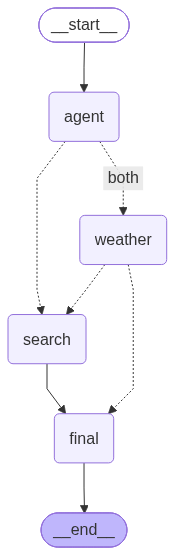

In [34]:
app

In [38]:
app.invoke( { "query": "What is the weather in Ranchi, Jharkhand today?" } )

{'query': 'What is the weather in Ranchi, Jharkhand today?',
 'decision': 'weather',
 'weather_result': 'Ranchi, India: 27.0°C, Light rain shower, Humidity 81%, Wind 11.9 kph',
 'final_response': "**Current Weather in Ranchi, Jharkhand:**\n\nAs of today, the weather in Ranchi, Jharkhand is:\n\n* Temperature: 27.0°C\n* Conditions: Light rain shower\n* Humidity: 81%\n* Wind Speed: 11.9 kph\n\nPlease note that weather conditions are subject to change. It's always a good idea to check for updates for the most accurate information."}

In [40]:
app.invoke( { "query": "I want to go to Ranchi, Jharkhand tomorrow to meet my family. Check weather and current news related to protests. should I plan or not?" } )

{'query': 'I want to go to Ranchi, Jharkhand tomorrow to meet my family. Check weather and current news related to protests. should I plan or not?',
 'decision': 'both',
 'weather_result': 'Ranchi, India: 27.0°C, Light rain shower, Humidity 81%, Wind 11.9 kph',
 'search_result': {'query': 'I want to go to Ranchi, Jharkhand tomorrow to meet my family. Check weather and current news related to protests. should I plan or not?',
  'follow_up_questions': None,
  'answer': None,
  'images': [],
  'results': [{'url': 'https://indianexpress.com/section/weather/ranchi-weather-forecast-today',
    'title': 'Ranchi Weather Today: Ranchi Temperature, Hourly Forecast (Friday, Aug 07, 2026) | The Indian Express',
    'content': 'Today in Ranchi, the weather will start in the morning with Light Rain at around 24.5°C, humidity close to 90%. It will feel like 28°C with 56% cloud cover.\n\nBy afternoon, conditions turn Rain Shower, with the temperature rising to 28.2°C and a UV index of 10.2. Winds from